In [1]:
import pandas as pd 

In [2]:
#Load dataset 
df = pd.read_csv("cleaned_retailed_dataset.csv")

# Retail Sales Demand Forecasting & Inventory Management System

### Machine Learning Project

**Objective:** Forecast product demand and identify potential stock-risk situations to support inventory reorder decisions.

**Tools:** Python, Pandas, NumPy, Matplotlib, Scikit-learn

**Final Model:** Random Forest Regressor

# EDA 

In [3]:
# EDA - STEP 1: BASIC OVERVIEW

print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of dataset:
(4956, 17)

Columns:
['Product_ID', 'Product_Name', 'Category', 'Brand', 'Date', 'Store_ID', 'Store_Location', 'Sales_Quantity', 'Unit_Price', 'Inventory_Level', 'Reorder_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Reorder_Required']

Data Types:
Product_ID           object
Product_Name         object
Category             object
Brand                object
Date                 object
Store_ID             object
Store_Location       object
Sales_Quantity      float64
Unit_Price          float64
Inventory_Level     float64
Reorder_Level         int64
Discount            float64
Holiday              object
Weather              object
Revenue             float64
Supplier             object
Reorder_Required     object
dtype: object


In [4]:
# EDA - STEP 2: NUMERICAL SUMMARY

df.describe()

,Sales_Quantity,Unit_Price,Inventory_Level,Reorder_Level,Discount,Revenue
count,4956.000000,4956.000000,4956.000000,4956.0,4956.000000,4956.000000
mean,44.646893,360.007667,159.969253,50.0,9.922316,13399.438095
std,84.678720,173.862023,79.117475,0.0,7.017998,10271.494095
min,5.000000,33.000000,20.000000,50.0,0.000000,158.400000
25%,24.000000,225.000000,93.000000,50.0,5.000000,5011.725000
50%,41.000000,380.000000,159.883056,50.0,10.000000,10939.500000
75%,59.000000,537.000000,226.000000,50.0,15.000000,19760.400000
max,3750.000000,599.000000,300.000000,50.0,20.000000,57812.000000


In [5]:
# EDA - STEP 3: CATEGORICAL VALUE COUNTS

categorical_columns = [
    "Product_Name",
    "Category",
    "Brand",
    "Store_Location",
    "Holiday",
    "Weather",
    "Supplier",
    "Reorder_Required"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Product_Name:
Product_Name
Yogurt           175
Juice            120
Paneer           118
Shampoo          115
Popcorn          114
Toothpaste       112
Wheat Flour      110
Cleaner          109
Cookies          107
Spices           106
Poha             105
Tea              104
Hand Wash        104
Body Lotion      103
Pasta            103
Biscuits         103
Butter           101
Deodorant        100
Curd             100
Tissue            99
Milk              98
Chocolate         98
Rice              97
Dishwash          97
Air Freshener     97
Face Cream        97
Cooking Oil       96
Hair Oil          96
Phenyl            96
Lassi             95
Floor Cleaner     95
Garbage Bags      94
Brush             93
Soap              92
Noodles           92
Chips             92
Face Wash         92
Salt              91
Soft Drink        91
Cheese            90
Detergent         90
Namkeen           90
Cream             88
Dal               86
Buttermilk        86
Sugar             86
Ghee  

In [6]:

# EDA - STEP 4: CORRELATION

numeric_columns = [
    "Sales_Quantity",
    "Unit_Price",
    "Inventory_Level",
    "Reorder_Level",
    "Discount",
    "Revenue"
]

df[numeric_columns].corr()

,Sales_Quantity,Unit_Price,Inventory_Level,Reorder_Level,Discount,Revenue
Sales_Quantity,1.000000,-0.025140,-0.020622,NaN,-0.020689,0.167182
Unit_Price,-0.025140,1.000000,0.010937,NaN,0.043980,0.610887
Inventory_Level,-0.020622,0.010937,1.000000,NaN,-0.003860,0.002410
Reorder_Level,NaN,NaN,NaN,NaN,NaN,NaN
Discount,-0.020689,0.043980,-0.003860,NaN,1.000000,-0.077839
Revenue,0.167182,0.610887,0.002410,NaN,-0.077839,1.000000


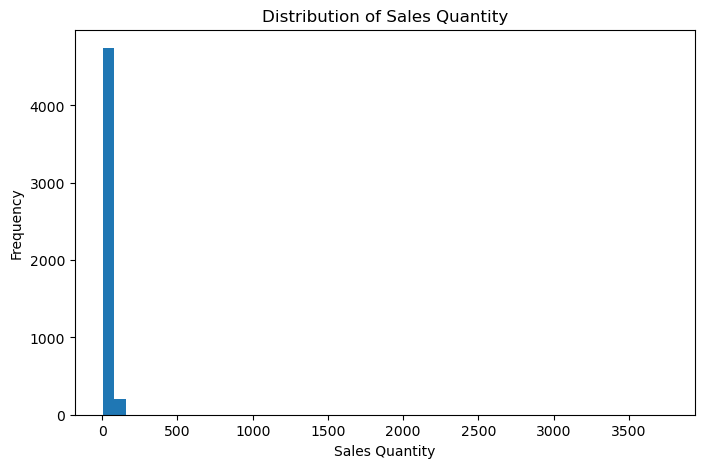

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Sales_Quantity"], bins=50)
plt.xlabel("Sales Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Sales Quantity")
plt.show()

In [8]:
# EDA - STEP 6: CHECK SALES QUANTITY OUTLIERS

Q1 = df["Sales_Quantity"].quantile(0.25)
Q3 = df["Sales_Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df["Sales_Quantity"] < lower_bound) |
    (df["Sales_Quantity"] > upper_bound)
]

print("\nNumber of outliers:", len(outliers))

Q1: 24.0
Q3: 59.0
IQR: 35.0
Lower Bound: -28.5
Upper Bound: 111.5

Number of outliers: 8


In [9]:
# EDA - STEP 7: INSPECT OUTLIERS

outliers[[
    "Product_Name",
    "Category",
    "Date",
    "Store_Location",
    "Sales_Quantity",
    "Discount",
    "Holiday",
    "Weather",
    "Revenue"
]]

,Product_Name,Category,Date,Store_Location,Sales_Quantity,Discount,Holiday,Weather,Revenue
1703,Sugar,Grocery,2025-01-11,Kakinada,1200.0,5.0,No,Cloudy,3579.6
2535,Noodles,Snacks,2025-04-15,Kurnool,1050.0,15.0,No,Sunny,5176.5
2969,Hand Wash,Personal Care,2025-07-03,GUNTUR,1850.0,10.0,No,Cloudy,3729.6
3128,Dal,Grocery,2025-08-14,Guntur,2700.0,5.0,No,Cloudy,2359.8
4138,Hand Wash,Personal Care,2025-10-19,Kakinada,1000.0,0.0,No,Cloudy,2240.0
4257,Juice,Snacks,2025-03-03,Nellore,2350.0,0.0,No,Rainy,25239.0
4303,Poha,Grocery,2025-11-07,Kakinada,3750.0,10.0,No,Cloudy,27270.0
4938,Shampoo,Personal Care,2025-11-13,Guntur,800.0,0.0,No,Sunny,768.0


In [10]:
# EDA - STEP 8: SALES QUANTITY BY CATEGORY

df.groupby("Category")["Sales_Quantity"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Category,,,,
dairy,43,36.395349,31.0,97.0
grocery,38,39.078947,36.0,74.0
household,34,30.852941,28.5,78.0
personal care,42,35.928571,38.0,75.0
snacks,41,37.731707,40.0,87.0
Dairy,953,41.138510,41.0,98.0
Grocery,941,50.737513,42.0,3750.0
Household,929,42.375673,41.0,103.0
Personal Care,959,45.642336,41.0,1850.0


In [11]:
# EDA - STEP 9: SALES QUANTITY BY STORE

df.groupby("Store_Location")["Sales_Quantity"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Store_Location,,,,
GUNTUR,17,147.235294,41.0,1850.0
Guntur,438,47.890411,40.0,2700.0
HYDERABAD,24,44.500000,43.5,85.0
Hyderabad,437,42.901602,43.0,103.0
KAKINADA,24,38.250000,40.0,85.0
KURNOOL,24,39.833333,43.5,69.0
Kakinada,473,52.942918,41.0,3750.0
Kurnool,463,45.280778,42.0,1050.0
NELLORE,24,36.666667,33.5,87.0


In [12]:
# EDA - STEP 10: SALES OVER TIME

df["Date"] = pd.to_datetime(df["Date"])

daily_sales = df.groupby("Date")["Sales_Quantity"].sum()

print(daily_sales.head())
print("\nNumber of dates:", len(daily_sales))

Date
2025-01-01    473.0
2025-01-02    558.0
2025-01-03    428.0
2025-01-04    674.0
2025-01-05    542.0
Name: Sales_Quantity, dtype: float64

Number of dates: 365


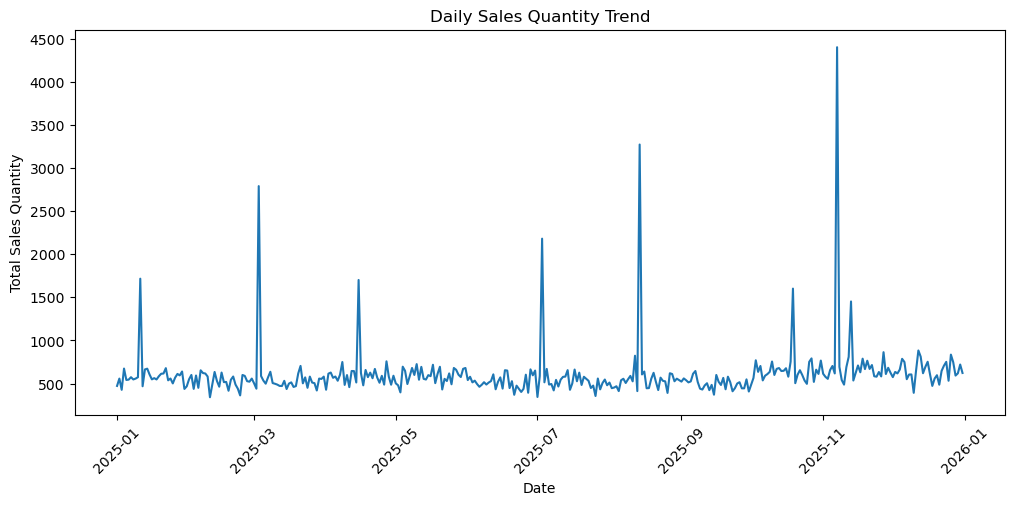

In [13]:
# EDA - STEP 11: SALES TREND

plt.figure(figsize=(12, 5))

plt.plot(daily_sales)

plt.xlabel("Date")
plt.ylabel("Total Sales Quantity")
plt.title("Daily Sales Quantity Trend")
plt.xticks(rotation=45)

plt.show()

In [14]:
# EDA - STEP 12: HOLIDAY VS SALES

df.groupby("Holiday")["Sales_Quantity"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Holiday,,,,
No,4767,44.222572,41.0,3750.0
Yes,179,56.374302,58.0,109.0
unknown,10,37.000000,38.5,68.0


# Pre Processing

In [15]:
# PREPROCESSING - STEP 1: DATE FEATURES

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

print(df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head())

        Date  Year  Month  Day  DayOfWeek
0 2025-03-14  2025      3   14          4
1 2025-03-24  2025      3   24          0
2 2025-03-20  2025      3   20          3
3 2025-12-31  2025     12   31          2
4 2025-05-01  2025      5    1          3


In [16]:
# PREPROCESSING - STEP 2: REMOVE ORIGINAL DATE

df = df.drop("Date", axis=1)

print(df.columns.tolist())

['Product_ID', 'Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Sales_Quantity', 'Unit_Price', 'Inventory_Level', 'Reorder_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Reorder_Required', 'Year', 'Month', 'Day', 'DayOfWeek']


In [17]:
# PREPROCESSING - STEP 3: CATEGORICAL COLUMNS

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns.tolist())

['Product_ID', 'Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Holiday', 'Weather', 'Supplier', 'Reorder_Required']


In [18]:
# PREPROCESSING - STEP 4: NORMALIZE CATEGORICAL TEXT

text_columns = [
    "Product_Name",
    "Category",
    "Brand",
    "Store_Location",
    "Holiday",
    "Weather",
    "Supplier",
    "Reorder_Required"
]

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

print(df[text_columns].head())

  Product_Name       Category       Brand Store_Location Holiday Weather  \
0       Yogurt          Dairy  Surf Excel    Rajahmundry      No   Rainy   
1   Buttermilk          Dairy  Surf Excel     Vijayawada      No   Rainy   
2       Yogurt          Dairy  Surf Excel    Rajahmundry      No  Cloudy   
3         Soap  Personal Care   Patanjali        Nellore      No  Cloudy   
4       Spices        Grocery  Surf Excel     Vijayawada      No   Sunny   

                   Supplier Reorder_Required  
0               Abc Traders               No  
1       Freshmart Suppliers               No  
2  Daily Needs Distributors               No  
3                 Retailhub               No  
4  Daily Needs Distributors               No  


In [19]:
# PREPROCESSING - STEP 5: UNIQUE CATEGORIES

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Product_ID: 50 unique values
Product_Name: 50 unique values
Category: 5 unique values
Brand: 10 unique values
Store_ID: 10 unique values
Store_Location: 10 unique values
Holiday: 3 unique values
Weather: 3 unique values
Supplier: 5 unique values
Reorder_Required: 2 unique values


In [20]:
# PREPROCESSING - STEP 6: REMOVE UNNECESSARY COLUMNS

df = df.drop(["Product_ID"], axis=1)

print(df.columns.tolist())

['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Sales_Quantity', 'Unit_Price', 'Inventory_Level', 'Reorder_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Reorder_Required', 'Year', 'Month', 'Day', 'DayOfWeek']


In [21]:
# PREPROCESSING - STEP 7: CHECK CONSTANT COLUMN

print(df["Reorder_Level"].nunique())

1


In [22]:
# PREPROCESSING - STEP 8: REMOVE CONSTANT COLUMN

df = df.drop("Reorder_Level", axis=1)

print(df.columns.tolist())

['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Sales_Quantity', 'Unit_Price', 'Inventory_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Reorder_Required', 'Year', 'Month', 'Day', 'DayOfWeek']


In [23]:
# PREPROCESSING - STEP 9: SEPARATE DEMAND TARGET

y_demand = df["Sales_Quantity"]

print(y_demand.head())
print("\nTarget shape:", y_demand.shape)

0    52.0
1    67.0
2    11.0
3    10.0
4    52.0
Name: Sales_Quantity, dtype: float64

Target shape: (4956,)


In [24]:
# PREPROCESSING - STEP 10: CREATE DEMAND FEATURES

X_demand = df.drop(["Sales_Quantity", "Reorder_Required"], axis=1)

print(X_demand.shape)
print(X_demand.columns.tolist())

(4956, 16)
['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Unit_Price', 'Inventory_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Year', 'Month', 'Day', 'DayOfWeek']


In [25]:
# PREPROCESSING - STEP 11: SEPARATE REORDER TARGET

y_reorder = df["Reorder_Required"]

print(y_reorder.value_counts())
print("\nTarget shape:", y_reorder.shape)

Reorder_Required
No     4435
Yes     521
Name: count, dtype: int64

Target shape: (4956,)


In [26]:
# PREPROCESSING - STEP 12: REMOVE POTENTIAL TARGET LEAKAGE

X_demand = X_demand.drop("Revenue", axis=1)

print(X_demand.shape)
print(X_demand.columns.tolist())

(4956, 15)
['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Unit_Price', 'Inventory_Level', 'Discount', 'Holiday', 'Weather', 'Supplier', 'Year', 'Month', 'Day', 'DayOfWeek']


In [27]:
# PREPROCESSING - STEP 13: IDENTIFY CATEGORICAL FEATURES

categorical_features = X_demand.select_dtypes(include="object").columns.tolist()

print(categorical_features)

['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Holiday', 'Weather', 'Supplier']


In [28]:
# PREPROCESSING - STEP 14: CREATE ONE-HOT ENCODER

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

print("Encoder created successfully")

Encoder created successfully


In [29]:
# PREPROCESSING - STEP 15: FIT ENCODER

encoder.fit(X_demand[categorical_features])

print("Encoder fitted successfully")

Encoder fitted successfully


In [30]:
# PREPROCESSING - STEP 16: TRANSFORM CATEGORICAL FEATURES

encoded_categorical = encoder.transform(X_demand[categorical_features])

print("Encoded shape:", encoded_categorical.shape)


Encoded shape: (4956, 96)


In [31]:
# PREPROCESSING - STEP 17: SELECT NUMERICAL FEATURES

numerical_features = X_demand.select_dtypes(exclude="object").columns.tolist()

print(numerical_features)
print("\nNumber of numerical features:", len(numerical_features))

['Unit_Price', 'Inventory_Level', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek']

Number of numerical features: 7


In [32]:
# PREPROCESSING - STEP 18: EXTRACT NUMERICAL FEATURES

numerical_data = X_demand[numerical_features].values

print("Numerical data shape:", numerical_data.shape)

Numerical data shape: (4956, 7)


In [33]:
# PREPROCESSING - STEP 19: COMBINE FEATURES

import numpy as np

X_processed = np.hstack([numerical_data, encoded_categorical])

print("Processed feature shape:", X_processed.shape)

Processed feature shape: (4956, 103)


In [34]:
# PREPROCESSING - STEP 20: SCALE NUMERICAL FEATURES

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_numerical = scaler.fit_transform(numerical_data)

print("Scaled numerical shape:", scaled_numerical.shape)

Scaled numerical shape: (4956, 7)


In [35]:
# PREPROCESSING - STEP 21: CREATE FINAL FEATURE MATRIX

X_processed = np.hstack([scaled_numerical, encoded_categorical])

print("Final feature shape:", X_processed.shape)

Final feature shape: (4956, 103)


In [36]:
# PREPROCESSING - STEP 22: CHECK FEATURES AND TARGET

print("X shape:", X_processed.shape)
print("y shape:", y_demand.shape)
print("Target name:", y_demand.name)

X shape: (4956, 103)
y shape: (4956,)
Target name: Sales_Quantity


In [37]:
# STEP 23: CREATE CHRONOLOGICAL ORDER

date_order = (
    df["Year"] * 10000
    + df["Month"] * 100
    + df["Day"]
)

print(date_order.head())

0    20250314
1    20250324
2    20250320
3    20251231
4    20250501
dtype: int32


In [38]:
# STEP 24: SORT FEATURES AND TARGET BY DATE

sort_index = np.argsort(date_order.values)

X_processed = X_processed[sort_index]
y_demand_sorted = y_demand.iloc[sort_index]

print("X shape:", X_processed.shape)
print("y shape:", y_demand_sorted.shape)

X shape: (4956, 103)
y shape: (4956,)


In [39]:
# STEP 25: TIME-BASED TRAIN-TEST SPLIT

split_index = int(len(X_processed) * 0.8)

X_train = X_processed[:split_index]
X_test = X_processed[split_index:]

y_train = y_demand_sorted.iloc[:split_index]
y_test = y_demand_sorted.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3964, 103)
X_test: (992, 103)
y_train: (3964,)
y_test: (992,)


In [40]:
# STEP 26: CREATE RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

print("Random Forest Regressor created successfully")

Random Forest Regressor created successfully


In [41]:
# STEP 27: TRAIN RANDOM FOREST REGRESSOR

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [42]:
# STEP 28: PREDICT ON TEST DATA

y_pred = model.predict(X_test)

print("Predictions created:", len(y_pred))
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions created: 992

First 10 predictions:
[43.42 60.17 60.92 50.67 51.13 47.08 39.14 49.58 58.43 48.42]


In [43]:
# STEP 29: EVALUATE DEMAND MODEL

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 29.773336693548387
MSE : 16844.270796471774
RMSE: 129.78547991386316
R²  : -0.06286633046696188


In [44]:
# STEP 30: COMPARE ACTUAL VS PREDICTED

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0    54.0      43.42
1    18.0      60.17
2    14.0      60.92
3    40.0      50.67
4    39.0      51.13
5    55.0      47.08
6    13.0      39.14
7    52.0      49.58
8    10.0      58.43
9    75.0      48.42


In [45]:
# STEP 31: CHECK TEST TARGET DISTRIBUTION

print(y_test.describe())

count     992.000000
mean       55.897177
std       125.952210
min         6.000000
25%        31.000000
50%        50.000000
75%        71.000000
max      3750.000000
Name: Sales_Quantity, dtype: float64


In [46]:
# STEP 32: COUNT HIGH-DEMAND VALUES

high_demand = y_test[y_test > 100]

print("Number of values above 100:", len(high_demand))
print("\nHigh-demand values:")
print(high_demand.values)

Number of values above 100: 5

High-demand values:
[1000. 3750.  800.  108.  109.]


In [47]:
# STEP 33: MAE FOR NORMAL DEMAND

normal_mask = y_test <= 100

mae_normal = mean_absolute_error(
    y_test[normal_mask],
    y_pred[normal_mask]
)

print("MAE for demand <= 100:", mae_normal)

MAE for demand <= 100: 24.425410334346505


In [48]:
# STEP 34: CHECK PREDICTION ERRORS

errors = y_test.values - y_pred

print("Mean Error:", errors.mean())
print("Minimum Error:", errors.min())
print("Maximum Error:", errors.max())

Mean Error: 3.1007358870967736
Minimum Error: -539.51
Maximum Error: 3698.86


In [49]:
# STEP 35: FIND BIGGEST PREDICTION ERRORS

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute_Error"] = abs(comparison["Error"])

print(
    comparison.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

     Actual  Predicted    Error  Absolute_Error
296  3750.0      51.14  3698.86         3698.86
50   1000.0      57.14   942.86          942.86
376   800.0     125.82   674.18          674.18
965    58.0     597.51  -539.51          539.51
636    15.0     431.76  -416.76          416.76
956    26.0     416.40  -390.40          390.40
625    52.0     416.53  -364.53          364.53
953    85.0     412.06  -327.06          327.06
151    88.0     404.91  -316.91          316.91
508    22.0     182.48  -160.48          160.48


In [50]:
# STEP 36: CHECK EXTREME TRAINING VALUES

print("Training values above 100:")
print(y_train[y_train > 100].values)

print("\nNumber of training values above 100:",
      (y_train > 100).sum())

Training values above 100:
[1200. 2350. 1050. 1850. 2700.  103.  103.]

Number of training values above 100: 7


In [51]:
# STEP 37: R² FOR NORMAL DEMAND

r2_normal = r2_score(
    y_test[normal_mask],
    y_pred[normal_mask]
)

print("R² for demand <= 100:", r2_normal)

R² for demand <= 100: -1.8266055086499677


In [52]:
# STEP 38: COMPARE TRAINING AND TEST DEMAND

print("Training mean:", y_train.mean())
print("Test mean:", y_test.mean())

print("\nTraining median:", y_train.median())
print("Test median:", y_test.median())

Training mean: 41.83148335015136
Test mean: 55.89717741935484

Training median: 41.0
Test median: 50.0


In [53]:

# STEP 39: CHECK MONTHLY DEMAND

monthly_demand = df.groupby("Month")["Sales_Quantity"].mean()

print(monthly_demand)

Month
1     42.839450
2     38.615584
3     42.965116
4     44.318182
5     42.614849
6     37.294964
7     41.442890
8     44.672093
9     37.773300
10    51.627500
11    61.881748
12    51.012690
Name: Sales_Quantity, dtype: float64


In [54]:
# STEP 40: TEST-SET MONTHLY DEMAND

test_months = df.iloc[y_test.index].groupby("Month")["Sales_Quantity"].mean()

print(test_months)

Month
10    53.966507
11    61.881748
12    51.012690
Name: Sales_Quantity, dtype: float64


In [55]:
# STEP 41: CREATE IMPROVED RANDOM FOREST

model_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

print("Improved Random Forest created successfully")

Improved Random Forest created successfully


In [56]:
# STEP 42: TRAIN IMPROVED RANDOM FOREST

model_v2.fit(X_train, y_train)

print("Improved model trained successfully")

Improved model trained successfully


In [57]:
# STEP 43: PREDICTIONS FROM IMPROVED MODEL

y_pred_v2 = model_v2.predict(X_test)

print("Predictions created:", len(y_pred_v2))
print("\nFirst 10 predictions:")
print(y_pred_v2[:10])

Predictions created: 992

First 10 predictions:
[46.55333333 58.69       63.05666667 51.13666667 47.74333333 47.83
 38.82       50.21       60.26       48.68      ]


In [58]:
# STEP 44: EVALUATE IMPROVED MODEL

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
mse_v2 = mean_squared_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2 = r2_score(y_test, y_pred_v2)

print("MAE :", mae_v2)
print("MSE :", mse_v2)
print("RMSE:", rmse_v2)
print("R²  :", r2_v2)

MAE : 29.530853494623656
MSE : 16606.8319452733
RMSE: 128.86749762943836
R²  : -0.04788403983930967


In [59]:
# STEP 45: CHECK DAY-OF-WEEK DEMAND

weekly_demand = df.groupby("DayOfWeek")["Sales_Quantity"].mean()

print(weekly_demand)

DayOfWeek
0    44.354196
1    43.166432
2    41.504155
3    48.923621
4    47.049365
5    44.378531
6    43.196275
Name: Sales_Quantity, dtype: float64


In [60]:
# STEP 46: ACTUAL VS PREDICTED BY MONTH

test_data = df.loc[y_test.index].copy()

test_data["Predicted"] = y_pred_v2

monthly_comparison = test_data.groupby("Month").agg(
    Actual=("Sales_Quantity", "mean"),
    Predicted=("Predicted", "mean")
)

print(monthly_comparison)

          Actual  Predicted
Month                      
10     53.966507  51.854721
11     61.881748  50.220420
12     51.012690  55.570491


In [61]:
# STEP 47: CHECK DATA STRUCTURE BY DATE

date_counts = df.groupby(
    ["Year", "Month", "Day"]
).size()

print(date_counts.describe())
print("\nFirst 10 dates:")
print(date_counts.head(10))

count    365.000000
mean      13.578082
std        0.746833
min       11.000000
25%       13.000000
50%       14.000000
75%       14.000000
max       16.000000
dtype: float64

First 10 dates:
Year  Month  Day
2025  1      1      14
             2      14
             3      15
             4      14
             5      15
             6      14
             7      14
             8      14
             9      14
             10     16
dtype: int64


In [62]:
# STEP 48: CALCULATE TOTAL DAILY DEMAND

daily_demand = df.groupby(
    ["Year", "Month", "Day"]
)["Sales_Quantity"].sum()

print(daily_demand.head(10))
print("\nDaily demand statistics:")
print(daily_demand.describe())

Year  Month  Day
2025  1      1      473.0
             2      558.0
             3      428.0
             4      674.0
             5      542.0
             6      546.0
             7      574.0
             8      548.0
             9      558.0
             10     574.0
Name: Sales_Quantity, dtype: float64

Daily demand statistics:
count     365.000000
mean      606.219178
std       317.789742
min       342.000000
25%       502.000000
50%       563.000000
75%       628.000000
max      4399.000000
Name: Sales_Quantity, dtype: float64


In [63]:
# STEP 49: RECREATE DATE FOR TIME-SERIES FEATURES

df["Date_New"] = pd.to_datetime(
    df[["Year", "Month", "Day"]]
)

print(df[["Year", "Month", "Day", "Date_New"]].head())

   Year  Month  Day   Date_New
0  2025      3   14 2025-03-14
1  2025      3   24 2025-03-24
2  2025      3   20 2025-03-20
3  2025     12   31 2025-12-31
4  2025      5    1 2025-05-01


In [64]:
# STEP 50: CREATE DAILY DEMAND TABLE

daily_demand_df = (
    df.groupby("Date_New")["Sales_Quantity"]
    .sum()
    .reset_index()
)

daily_demand_df.columns = ["Date_New", "Daily_Demand"]

print(daily_demand_df.head())
print("\nShape:", daily_demand_df.shape)

    Date_New  Daily_Demand
0 2025-01-01         473.0
1 2025-01-02         558.0
2 2025-01-03         428.0
3 2025-01-04         674.0
4 2025-01-05         542.0

Shape: (365, 2)


In [65]:
# STEP 51: CREATE PREVIOUS-DAY DEMAND

daily_demand_df["Previous_Day_Demand"] = (
    daily_demand_df["Daily_Demand"].shift(1)
)

print(daily_demand_df.head(10))

    Date_New  Daily_Demand  Previous_Day_Demand
0 2025-01-01         473.0                  NaN
1 2025-01-02         558.0                473.0
2 2025-01-03         428.0                558.0
3 2025-01-04         674.0                428.0
4 2025-01-05         542.0                674.0
5 2025-01-06         546.0                542.0
6 2025-01-07         574.0                546.0
7 2025-01-08         548.0                574.0
8 2025-01-09         558.0                548.0
9 2025-01-10         574.0                558.0


In [66]:
# STEP 52: CREATE 7-DAY ROLLING DEMAND

daily_demand_df["Rolling_7_Day_Demand"] = (
    daily_demand_df["Daily_Demand"]
    .rolling(window=7)
    .mean()
)

print(daily_demand_df.head(10))

    Date_New  Daily_Demand  Previous_Day_Demand  Rolling_7_Day_Demand
0 2025-01-01         473.0                  NaN                   NaN
1 2025-01-02         558.0                473.0                   NaN
2 2025-01-03         428.0                558.0                   NaN
3 2025-01-04         674.0                428.0                   NaN
4 2025-01-05         542.0                674.0                   NaN
5 2025-01-06         546.0                542.0                   NaN
6 2025-01-07         574.0                546.0            542.142857
7 2025-01-08         548.0                574.0            552.857143
8 2025-01-09         558.0                548.0            552.857143
9 2025-01-10         574.0                558.0            573.714286


In [67]:
# STEP 53: CHECK LAG FEATURE VALID VALUES

print("Previous Day missing values:",
      daily_demand_df["Previous_Day_Demand"].isna().sum())

print("Rolling 7-Day missing values:",
      daily_demand_df["Rolling_7_Day_Demand"].isna().sum())

Previous Day missing values: 1
Rolling 7-Day missing values: 6


In [68]:
# STEP 54: MERGE DAILY DEMAND FEATURES

df = df.merge(
    daily_demand_df[
        ["Date_New", "Previous_Day_Demand", "Rolling_7_Day_Demand"]
    ],
    on="Date_New",
    how="left"
)

print(df[[
    "Date_New",
    "Sales_Quantity",
    "Previous_Day_Demand",
    "Rolling_7_Day_Demand"
]].head(10))

    Date_New  Sales_Quantity  Previous_Day_Demand  Rolling_7_Day_Demand
0 2025-03-14            52.0                472.0            515.142857
1 2025-03-24            67.0                572.0            540.000000
2 2025-03-20            11.0                471.0            504.571429
3 2025-12-31            10.0                721.0            667.571429
4 2025-05-01            52.0                591.0            571.000000
5 2025-01-23            43.0                679.0            592.000000
6 2025-12-27            41.0                836.0            672.857143
7 2025-08-02            13.0                512.0            497.857143
8 2025-03-20            45.0                471.0            504.571429
9 2025-04-01            47.0                581.0            508.428571


In [69]:
# STEP 55: REMOVE ROWS WITHOUT LAG HISTORY

df_forecast = df.dropna(
    subset=[
        "Previous_Day_Demand",
        "Rolling_7_Day_Demand"
    ]
).copy()

print("Original rows:", len(df))
print("Forecasting rows:", len(df_forecast))
print("Rows removed:", len(df) - len(df_forecast))

Original rows: 4956
Forecasting rows: 4870
Rows removed: 86


In [70]:
# STEP 56: CHECK NEW FEATURES

print(df_forecast[[
    "Previous_Day_Demand",
    "Rolling_7_Day_Demand"
]].describe())

       Previous_Day_Demand  Rolling_7_Day_Demand
count          4870.000000           4870.000000
mean            605.777002            604.998299
std             318.401618            128.033886
min             342.000000            443.428571
25%             501.000000            524.142857
50%             562.000000            568.142857
75%             627.000000            647.428571
max            4399.000000           1296.428571


In [71]:
# STEP 57: CREATE SAFE 7-DAY ROLLING DEMAND

daily_demand_df["Previous_7_Day_Avg"] = (
    daily_demand_df["Daily_Demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

print(daily_demand_df.head(10))

    Date_New  Daily_Demand  Previous_Day_Demand  Rolling_7_Day_Demand  \
0 2025-01-01         473.0                  NaN                   NaN   
1 2025-01-02         558.0                473.0                   NaN   
2 2025-01-03         428.0                558.0                   NaN   
3 2025-01-04         674.0                428.0                   NaN   
4 2025-01-05         542.0                674.0                   NaN   
5 2025-01-06         546.0                542.0                   NaN   
6 2025-01-07         574.0                546.0            542.142857   
7 2025-01-08         548.0                574.0            552.857143   
8 2025-01-09         558.0                548.0            552.857143   
9 2025-01-10         574.0                558.0            573.714286   

   Previous_7_Day_Avg  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
5                 NaN  
6                 NaN  
7   

In [72]:
# STEP 58: MERGE SAFE 7-DAY FEATURE

daily_features_safe = daily_demand_df[
    ["Date_New", "Previous_Day_Demand", "Previous_7_Day_Avg"]
]

df_forecast = df_forecast.drop(
    columns=["Rolling_7_Day_Demand"]
)

df_forecast = df_forecast.merge(
    daily_features_safe,
    on=["Date_New", "Previous_Day_Demand"],
    how="left"
)

print(df_forecast[[
    "Date_New",
    "Sales_Quantity",
    "Previous_Day_Demand",
    "Previous_7_Day_Avg"
]].head(10))

    Date_New  Sales_Quantity  Previous_Day_Demand  Previous_7_Day_Avg
0 2025-03-14            52.0                472.0          520.857143
1 2025-03-24            67.0                572.0          549.000000
2 2025-03-20            11.0                471.0          483.857143
3 2025-12-31            10.0                721.0          686.000000
4 2025-05-01            52.0                591.0          572.000000
5 2025-01-23            43.0                679.0          593.571429
6 2025-12-27            41.0                836.0          651.285714
7 2025-08-02            13.0                512.0          484.857143
8 2025-03-20            45.0                471.0          483.857143
9 2025-04-01            47.0                581.0          530.142857


In [73]:
# STEP 59: CHECK SAFE FEATURE

print("Previous Day missing:",
      df_forecast["Previous_Day_Demand"].isna().sum())

print("Previous 7-Day Average missing:",
      df_forecast["Previous_7_Day_Avg"].isna().sum())

Previous Day missing: 0
Previous 7-Day Average missing: 14


In [74]:
# STEP 60: REMOVE REMAINING MISSING HISTORY

df_forecast = df_forecast.dropna(
    subset=["Previous_7_Day_Avg"]
).copy()

print("Rows after removing missing history:", len(df_forecast))
print(
    "Missing Previous 7-Day Average:",
    df_forecast["Previous_7_Day_Avg"].isna().sum()
)

Rows after removing missing history: 4856
Missing Previous 7-Day Average: 0


In [75]:
# STEP 61: CHECK FORECASTING DATASET COLUMNS

print(df_forecast.columns.tolist())

['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Sales_Quantity', 'Unit_Price', 'Inventory_Level', 'Discount', 'Holiday', 'Weather', 'Revenue', 'Supplier', 'Reorder_Required', 'Year', 'Month', 'Day', 'DayOfWeek', 'Date_New', 'Previous_Day_Demand', 'Previous_7_Day_Avg']


In [76]:
# STEP 62: CREATE UPDATED DEMAND FEATURES

y_demand_new = df_forecast["Sales_Quantity"]

X_demand_new = df_forecast.drop(
    ["Sales_Quantity", "Reorder_Required", "Revenue", "Date_New"],
    axis=1
)

print("X shape:", X_demand_new.shape)
print("y shape:", y_demand_new.shape)
print("Features:")
print(X_demand_new.columns.tolist())

X shape: (4856, 17)
y shape: (4856,)
Features:
['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Unit_Price', 'Inventory_Level', 'Discount', 'Holiday', 'Weather', 'Supplier', 'Year', 'Month', 'Day', 'DayOfWeek', 'Previous_Day_Demand', 'Previous_7_Day_Avg']


In [77]:
# STEP 63: IDENTIFY CATEGORICAL FEATURES

categorical_features_new = (
    X_demand_new
    .select_dtypes(include="object")
    .columns
    .tolist()
)

print(categorical_features_new)

['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Holiday', 'Weather', 'Supplier']


In [78]:
# STEP 64: CREATE ONE-HOT ENCODER

from sklearn.preprocessing import OneHotEncoder

encoder_new = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_new.fit(
    X_demand_new[categorical_features_new]
)

print("Encoder fitted successfully!")

Encoder fitted successfully!


In [79]:
# STEP 65: ENCODE CATEGORICAL FEATURES

encoded_categorical_new = encoder_new.transform(
    X_demand_new[categorical_features_new]
)

print("Encoded shape:", encoded_categorical_new.shape)

Encoded shape: (4856, 96)


In [80]:
# STEP 66: IDENTIFY NUMERICAL FEATURES

numerical_features_new = (
    X_demand_new
    .select_dtypes(exclude="object")
    .columns
    .tolist()
)

print(numerical_features_new)
print("Number of numerical features:", len(numerical_features_new))

['Unit_Price', 'Inventory_Level', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek', 'Previous_Day_Demand', 'Previous_7_Day_Avg']
Number of numerical features: 9


In [81]:
# STEP 67: EXTRACT NUMERICAL DATA

numerical_data_new = X_demand_new[numerical_features_new].values

print("Numerical data shape:", numerical_data_new.shape)

Numerical data shape: (4856, 9)


In [82]:
# STEP 68: SCALE NUMERICAL FEATURES

from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

scaled_numerical_new = scaler_new.fit_transform(
    numerical_data_new
)

print("Scaled numerical shape:", scaled_numerical_new.shape)

Scaled numerical shape: (4856, 9)


In [83]:
# STEP 69: COMBINE NUMERICAL + CATEGORICAL FEATURES

X_processed_new = np.hstack([
    scaled_numerical_new,
    encoded_categorical_new
])

print("Final X shape:", X_processed_new.shape)
print("y shape:", y_demand_new.shape)

Final X shape: (4856, 105)
y shape: (4856,)


In [84]:
# STEP 70: SORT DATA CHRONOLOGICALLY

sort_index_new = np.argsort(
    df_forecast["Date_New"].values
)

X_processed_new = X_processed_new[sort_index_new]
y_demand_sorted_new = y_demand_new.iloc[sort_index_new]

print("Data sorted chronologically!")
print("X shape:", X_processed_new.shape)
print("y shape:", y_demand_sorted_new.shape)

Data sorted chronologically!
X shape: (4856, 105)
y shape: (4856,)


In [85]:
# STEP 71: TIME-BASED TRAIN-TEST SPLIT

split_index_new = int(len(X_processed_new) * 0.8)

X_train_new = X_processed_new[:split_index_new]
X_test_new = X_processed_new[split_index_new:]

y_train_new = y_demand_sorted_new.iloc[:split_index_new]
y_test_new = y_demand_sorted_new.iloc[split_index_new:]

print("X_train:", X_train_new.shape)
print("X_test:", X_test_new.shape)
print("y_train:", y_train_new.shape)
print("y_test:", y_test_new.shape)

X_train: (3884, 105)
X_test: (972, 105)
y_train: (3884,)
y_test: (972,)


In [86]:

# STEP 72: TRAIN RANDOM FOREST V3

from sklearn.ensemble import RandomForestRegressor

model_v3 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_v3.fit(X_train_new, y_train_new)

print("Random Forest V3 trained successfully!")

Random Forest V3 trained successfully!


In [87]:
# STEP 73: GENERATE V3 PREDICTIONS

y_pred_v3 = model_v3.predict(X_test_new)

print("Predictions generated!")
print("Number of predictions:", len(y_pred_v3))
print("First 10 predictions:")
print(y_pred_v3[:10])

Predictions generated!
Number of predictions: 972
First 10 predictions:
[45.63333333 45.23333333 50.20666667 52.78       41.39666667 43.64
 55.05666667 44.70333333 46.13333333 62.48      ]


In [88]:
# STEP 74: EVALUATE RANDOM FOREST V3

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_v3 = mean_absolute_error(y_test_new, y_pred_v3)
mse_v3 = mean_squared_error(y_test_new, y_pred_v3)
rmse_v3 = np.sqrt(mse_v3)
r2_v3 = r2_score(y_test_new, y_pred_v3)

print("V3 MAE:", mae_v3)
print("V3 MSE:", mse_v3)
print("V3 RMSE:", rmse_v3)
print("V3 R²:", r2_v3)

V3 MAE: 29.146008230452676
V3 MSE: 16762.192242638317
V3 RMSE: 129.468885229766
V3 R²: -0.03716717152125071


In [89]:



# STEP 75: ACTUAL VS PREDICTED

comparison_v3 = pd.DataFrame({
    "Actual": y_test_new.values,
    "Predicted": y_pred_v3
})

print(comparison_v3.head(10))

   Actual  Predicted
0    29.0  45.633333
1    65.0  45.233333
2    52.0  50.206667
3     7.0  52.780000
4    36.0  41.396667
5     7.0  43.640000
6    77.0  55.056667
7    50.0  44.703333
8    72.0  46.133333
9    71.0  62.480000


In [90]:
# STEP 76: CHECK HIGH-DEMAND TEST VALUES

high_demand_v3 = y_test_new[y_test_new > 100]

print("High-demand values (>100):")
print(high_demand_v3.values)

print("Count:", len(high_demand_v3))

High-demand values (>100):
[1000. 3750.  800.  108.  109.]
Count: 5


In [91]:
# STEP 77: V3 PERFORMANCE ON NORMAL DEMAND

normal_mask_v3 = y_test_new <= 100

mae_normal_v3 = mean_absolute_error(
    y_test_new[normal_mask_v3],
    y_pred_v3[normal_mask_v3]
)

rmse_normal_v3 = np.sqrt(
    mean_squared_error(
        y_test_new[normal_mask_v3],
        y_pred_v3[normal_mask_v3]
    )
)

r2_normal_v3 = r2_score(
    y_test_new[normal_mask_v3],
    y_pred_v3[normal_mask_v3]
)

print("Normal-demand MAE:", mae_normal_v3)
print("Normal-demand RMSE:", rmse_normal_v3)
print("Normal-demand R²:", r2_normal_v3)

Normal-demand MAE: 23.631296104791453
Normal-demand RMSE: 34.70399485190307
Normal-demand R²: -0.997984788840669


In [92]:
# STEP 78: FIND BIGGEST V3 ERRORS

comparison_v3["Error"] = (
    comparison_v3["Actual"] - comparison_v3["Predicted"]
)

comparison_v3["Absolute_Error"] = (
    comparison_v3["Error"].abs()
)

biggest_errors_v3 = comparison_v3.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

print(biggest_errors_v3)

     Actual   Predicted        Error  Absolute_Error
271  3750.0   47.790000  3702.210000     3702.210000
34   1000.0   58.813333   941.186667      941.186667
347   800.0   71.763333   728.236667      728.236667
611    15.0  531.250000  -516.250000      516.250000
944    58.0  301.803333  -243.803333      243.803333
210    70.0  258.613333  -188.613333      188.613333
945    26.0  213.716667  -187.716667      187.716667
934    85.0  248.936667  -163.936667      163.936667
488    22.0  172.370000  -150.370000      150.370000
615    52.0  198.453333  -146.453333      146.453333


In [93]:
# STEP 79: INSPECT ROWS WITH LARGEST ERRORS

error_indices = biggest_errors_v3.index

print(
    df_forecast.loc[
        error_indices,
        [
            "Date_New",
            "Product_Name",
            "Category",
            "Store_ID",
            "Store_Location",
            "Sales_Quantity",
            "Unit_Price",
            "Inventory_Level",
            "Discount",
            "Holiday",
            "Weather"
        ]
    ]
)

      Date_New   Product_Name   Category Store_ID Store_Location  \
271 2025-11-04           Curd      Dairy     S007        Kurnool   
34  2025-11-29          Chips     Snacks     S004        Kurnool   
347 2025-10-30     Soft Drink     Snacks     S009       Warangal   
611 2025-03-15        Noodles     Snacks     S006     Vijayawada   
944 2025-02-06           Poha    Grocery     S002       Tirupati   
210 2025-10-12       Dishwash  Household     S003       Warangal   
945 2025-01-29         Tissue  Household     S002        Kurnool   
934 2025-03-05         Spices    Grocery     S008         Guntur   
488 2025-11-28        Cookies     Snacks     S007        Nellore   
615 2025-03-26  Air Freshener  Household     S007       Warangal   

     Sales_Quantity  Unit_Price  Inventory_Level  Discount Holiday Weather  
271            55.0       590.0            285.0       0.0      No  Cloudy  
34             29.0       543.0            288.0       5.0      No   Rainy  
347            65.0 

In [94]:
# STEP 80: CHECK LAG FEATURES FOR BIGGEST ERRORS

print(
    df_forecast.loc[
        error_indices,
        [
            "Date_New",
            "Sales_Quantity",
            "Previous_Day_Demand",
            "Previous_7_Day_Avg"
        ]
    ]
)

      Date_New  Sales_Quantity  Previous_Day_Demand  Previous_7_Day_Avg
271 2025-11-04            55.0                555.0          615.285714
34  2025-11-29            29.0                611.0          653.142857
347 2025-10-30            65.0                661.0          622.571429
611 2025-03-15            15.0                532.0          515.142857
944 2025-02-06            63.0                451.0          505.714286
210 2025-10-12            28.0                600.0          633.428571
945 2025-01-29            62.0                595.0          579.142857
934 2025-03-05             6.0                588.0          847.000000
488 2025-11-28            20.0                864.0          661.571429
615 2025-03-26            30.0                581.0          557.142857


In [95]:
# STEP 81: REMOVE UNSUITABLE LAG FEATURES

X_demand_no_lag = X_demand_new.drop(
    ["Previous_Day_Demand", "Previous_7_Day_Avg"],
    axis=1
)

print(X_demand_no_lag.shape)

(4856, 15)


In [96]:
# STEP 82: IDENTIFY FEATURES

categorical_features_new = X_demand_no_lag.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features_new = X_demand_no_lag.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:", categorical_features_new)
print("Numerical features:", numerical_features_new)

Categorical features: ['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Holiday', 'Weather', 'Supplier']
Numerical features: ['Unit_Price', 'Inventory_Level', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek']


In [97]:
# STEP 83: CREATE PREPROCESSING TRANSFORMERS

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_new = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_new),
        ("num", StandardScaler(), numerical_features_new)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [98]:
# STEP 84: TRANSFORM FEATURES

X_processed_no_lag = preprocessor_new.fit_transform(
    X_demand_no_lag
)

print(X_processed_no_lag.shape)

(4856, 103)


In [99]:
# STEP 85: SORT DATA CHRONOLOGICALLY

sort_index_no_lag = np.argsort(
    df_forecast["Date_New"].values
)

X_processed_no_lag = X_processed_no_lag[
    sort_index_no_lag
]

y_demand_no_lag = y_demand_new.iloc[
    sort_index_no_lag
]

print("Data sorted chronologically")
print("X shape:", X_processed_no_lag.shape)
print("y shape:", y_demand_no_lag.shape)

Data sorted chronologically
X shape: (4856, 103)
y shape: (4856,)


In [100]:
# STEP 86: TIME-BASED TRAIN-TEST SPLIT

split_index_no_lag = int(len(X_processed_no_lag) * 0.8)

X_train_no_lag = X_processed_no_lag[:split_index_no_lag]
X_test_no_lag = X_processed_no_lag[split_index_no_lag:]

y_train_no_lag = y_demand_no_lag.iloc[:split_index_no_lag]
y_test_no_lag = y_demand_no_lag.iloc[split_index_no_lag:]

print("X_train:", X_train_no_lag.shape)
print("X_test:", X_test_no_lag.shape)
print("y_train:", y_train_no_lag.shape)
print("y_test:", y_test_no_lag.shape)

X_train: (3884, 103)
X_test: (972, 103)
y_train: (3884,)
y_test: (972,)


In [101]:
# STEP 87: TRAIN RANDOM FOREST

model_no_lag = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_no_lag.fit(
    X_train_no_lag,
    y_train_no_lag
)

print("Model trained successfully")

Model trained successfully


In [102]:
# STEP 88: MAKE PREDICTIONS

y_pred_no_lag = model_no_lag.predict(
    X_test_no_lag
)

print(y_pred_no_lag[:10])

[45.90666667 42.77333333 49.93       50.58666667 43.47333333 48.39666667
 54.31       45.52       46.38       63.72333333]


In [103]:
# STEP 89: CALCULATE MAE

from sklearn.metrics import mean_absolute_error

mae_no_lag = mean_absolute_error(
    y_test_no_lag,
    y_pred_no_lag
)

print("MAE:", mae_no_lag)

MAE: 29.78712277091907


In [104]:
# STEP 90: CALCULATE MSE

from sklearn.metrics import mean_squared_error

mse_no_lag = mean_squared_error(
    y_test_no_lag,
    y_pred_no_lag
)

print("MSE:", mse_no_lag)

MSE: 17044.872943472794


In [105]:
# STEP 91: CALCULATE RMSE

import numpy as np

rmse_no_lag = np.sqrt(mse_no_lag)

print("RMSE:", rmse_no_lag)

RMSE: 130.55601458176025


In [106]:
# STEP 92: CALCULATE R²

from sklearn.metrics import r2_score

r2_no_lag = r2_score(
    y_test_no_lag,
    y_pred_no_lag
)

print("R²:", r2_no_lag)

R²: -0.05465814994961837


In [107]:
# STEP 93: NORMAL-DEMAND EVALUATION

normal_mask_no_lag = y_test_no_lag <= 100

mae_normal_no_lag = mean_absolute_error(
    y_test_no_lag[normal_mask_no_lag],
    y_pred_no_lag[normal_mask_no_lag]
)

rmse_normal_no_lag = np.sqrt(
    mean_squared_error(
        y_test_no_lag[normal_mask_no_lag],
        y_pred_no_lag[normal_mask_no_lag]
    )
)

print("Normal-demand MAE:", mae_normal_no_lag)
print("Normal-demand RMSE:", rmse_normal_no_lag)

Normal-demand MAE: 24.300113753877973
Normal-demand RMSE: 39.10719715177933


In [108]:
# STEP 94: COMPARE MODELS

print("V2 Random Forest")
print("MAE:", 30.1141)
print("R²:", -0.06654)

print("\nV3 Random Forest + Aggregate Lag Features")
print("MAE:", 29.1460)
print("R²:", -0.03717)

print("\nNo-Lag Random Forest")
print("MAE:", mae_no_lag)
print("R²:", r2_no_lag)

V2 Random Forest
MAE: 30.1141
R²: -0.06654

V3 Random Forest + Aggregate Lag Features
MAE: 29.146
R²: -0.03717

No-Lag Random Forest
MAE: 29.78712277091907
R²: -0.05465814994961837


In [109]:
# STEP 95: CREATE PRODUCT-STORE DEMAND HISTORY

product_store_demand = (
    df_forecast
    .groupby(
        ["Product_Name", "Store_ID", "Date_New"]
    )["Sales_Quantity"]
    .sum()
    .reset_index()
)

print(product_store_demand.head())
print("Shape:", product_store_demand.shape)

    Product_Name Store_ID   Date_New  Sales_Quantity
0  Air Freshener     S001 2025-03-29             6.0
1  Air Freshener     S001 2025-04-15            23.0
2  Air Freshener     S001 2025-05-01            12.0
3  Air Freshener     S001 2025-05-07            26.0
4  Air Freshener     S001 2025-06-15             8.0
Shape: (4793, 4)


In [110]:
# STEP 96: PREVIOUS DEMAND FOR SAME PRODUCT + STORE

product_store_demand = product_store_demand.sort_values(
    ["Product_Name", "Store_ID", "Date_New"]
)

product_store_demand["Previous_Product_Store_Demand"] = (
    product_store_demand
    .groupby(["Product_Name", "Store_ID"])["Sales_Quantity"]
    .shift(1)
)

print(product_store_demand.head(10))

    Product_Name Store_ID   Date_New  Sales_Quantity  \
0  Air Freshener     S001 2025-03-29             6.0   
1  Air Freshener     S001 2025-04-15            23.0   
2  Air Freshener     S001 2025-05-01            12.0   
3  Air Freshener     S001 2025-05-07            26.0   
4  Air Freshener     S001 2025-06-15             8.0   
5  Air Freshener     S001 2025-07-30            26.0   
6  Air Freshener     S001 2025-08-19            26.0   
7  Air Freshener     S001 2025-09-04            42.0   
8  Air Freshener     S001 2025-10-08            22.0   
9  Air Freshener     S001 2025-11-06            61.0   

   Previous_Product_Store_Demand  
0                            NaN  
1                            6.0  
2                           23.0  
3                           12.0  
4                           26.0  
5                            8.0  
6                           26.0  
7                           26.0  
8                           42.0  
9                           22.0 

In [111]:
# STEP 97: MERGE PRODUCT-STORE LAG INTO FORECAST DATA

df_forecast_v4 = df_forecast.merge(
    product_store_demand[
        [
            "Product_Name",
            "Store_ID",
            "Date_New",
            "Previous_Product_Store_Demand"
        ]
    ],
    on=["Product_Name", "Store_ID", "Date_New"],
    how="left"
)

print(df_forecast_v4.shape)
print(df_forecast_v4["Previous_Product_Store_Demand"].isna().sum())

(4856, 22)
507


In [112]:

# STEP 98: REMOVE ROWS WITHOUT PREVIOUS PRODUCT-STORE HISTORY

df_forecast_v4 = df_forecast_v4.dropna(
    subset=["Previous_Product_Store_Demand"]
).copy()

print("Shape after removing missing history:", df_forecast_v4.shape)
print(
    "Missing previous demand:",
    df_forecast_v4["Previous_Product_Store_Demand"].isna().sum()
)

Shape after removing missing history: (4349, 22)
Missing previous demand: 0


In [113]:
# STEP 99: CREATE V4 FEATURES AND TARGET

y_demand_v4 = df_forecast_v4["Sales_Quantity"]

X_demand_v4 = df_forecast_v4.drop(
    [
        "Sales_Quantity",
        "Reorder_Required",
        "Revenue",
        "Date_New",
        "Previous_Day_Demand",
        "Previous_7_Day_Avg"
    ],
    axis=1
)

print("X shape:", X_demand_v4.shape)
print("y shape:", y_demand_v4.shape)

X shape: (4349, 16)
y shape: (4349,)


In [114]:
# STEP 100: IDENTIFY CATEGORICAL AND NUMERICAL FEATURES

categorical_features_v4 = X_demand_v4.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features_v4 = X_demand_v4.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features_v4)

print("\nNumerical features:")
print(numerical_features_v4)

Categorical features:
['Product_Name', 'Category', 'Brand', 'Store_ID', 'Store_Location', 'Holiday', 'Weather', 'Supplier']

Numerical features:
['Unit_Price', 'Inventory_Level', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek', 'Previous_Product_Store_Demand']


In [115]:
# STEP 101: CREATE V4 PREPROCESSOR

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_v4 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_v4
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_v4
        )
    ]
)

print("V4 preprocessor created successfully.")

V4 preprocessor created successfully.


In [116]:
# STEP 102: TRANSFORM V4 FEATURES

X_processed_v4 = preprocessor_v4.fit_transform(X_demand_v4)

print("Processed X shape:", X_processed_v4.shape)

Processed X shape: (4349, 104)


In [117]:
# STEP 103: SORT DATA CHRONOLOGICALLY

sort_index_v4 = np.argsort(
    df_forecast_v4["Date_New"].values
)

X_processed_v4 = X_processed_v4[sort_index_v4]
y_demand_v4_sorted = y_demand_v4.iloc[sort_index_v4]

print("Sorted X shape:", X_processed_v4.shape)
print("Sorted y shape:", y_demand_v4_sorted.shape)

Sorted X shape: (4349, 104)
Sorted y shape: (4349,)


In [118]:
# STEP 104: TIME-BASED TRAIN-TEST SPLIT

split_index_v4 = int(len(X_processed_v4) * 0.8)

X_train_v4 = X_processed_v4[:split_index_v4]
X_test_v4 = X_processed_v4[split_index_v4:]

y_train_v4 = y_demand_v4_sorted.iloc[:split_index_v4]
y_test_v4 = y_demand_v4_sorted.iloc[split_index_v4:]

print("X_train:", X_train_v4.shape)
print("X_test:", X_test_v4.shape)
print("y_train:", y_train_v4.shape)
print("y_test:", y_test_v4.shape)

X_train: (3479, 104)
X_test: (870, 104)
y_train: (3479,)
y_test: (870,)


In [119]:
# STEP 105: TRAIN V4 RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

model_v4 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_v4.fit(X_train_v4, y_train_v4)

print("V4 Random Forest trained successfully.")

V4 Random Forest trained successfully.


In [120]:
# STEP 106: GENERATE V4 PREDICTIONS

y_pred_v4 = model_v4.predict(X_test_v4)

print("First 10 predictions:")
print(y_pred_v4[:10])


First 10 predictions:
[56.06       53.39666667 46.98333333 48.81333333 53.53333333 41.77333333
 47.53333333 52.47666667 47.97666667 46.73333333]


In [121]:
# STEP 107: EVALUATE V4 MODEL

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_v4 = mean_absolute_error(y_test_v4, y_pred_v4)
mse_v4 = mean_squared_error(y_test_v4, y_pred_v4)
rmse_v4 = np.sqrt(mse_v4)
r2_v4 = r2_score(y_test_v4, y_pred_v4)

print("V4 Random Forest")
print("MAE:", mae_v4)
print("MSE:", mse_v4)
print("RMSE:", rmse_v4)
print("R²:", r2_v4)

V4 Random Forest
MAE: 29.442735632183908
MSE: 17523.307888454663
RMSE: 132.37563177735797
R²: -0.03312102389193172


In [122]:
# STEP 108: V4 PERFORMANCE ON NORMAL DEMAND

normal_mask_v4 = y_test_v4 <= 100

mae_normal_v4 = mean_absolute_error(
    y_test_v4[normal_mask_v4],
    y_pred_v4[normal_mask_v4]
)

rmse_normal_v4 = np.sqrt(
    mean_squared_error(
        y_test_v4[normal_mask_v4],
        y_pred_v4[normal_mask_v4]
    )
)

print("Normal-demand rows:", normal_mask_v4.sum())
print("Normal-demand MAE:", mae_normal_v4)
print("Normal-demand RMSE:", rmse_normal_v4)

Normal-demand rows: 866
Normal-demand MAE: 24.4735103926097
Normal-demand RMSE: 35.818675579177174


In [123]:
# STEP 109: CHECK HIGH-DEMAND PREDICTIONS

high_mask_v4 = y_test_v4 > 100

print("Actual high-demand values:")
print(y_test_v4[high_mask_v4].values)

print("\nPredicted values:")
print(y_pred_v4[high_mask_v4])

Actual high-demand values:
[3750.  800.  108.  109.]

Predicted values:
[ 51.71666667 125.78        59.55333333 108.83      ]


In [124]:
# STEP 110: INSPECT HIGH-DEMAND ROWS

high_demand_rows_v4 = df_forecast_v4.iloc[
    np.where(
        df_forecast_v4["Date_New"].isin(
            df_forecast_v4["Date_New"].iloc[
                np.argsort(df_forecast_v4["Date_New"].values)
            ].iloc[split_index_v4:]
        )
        & (df_forecast_v4["Sales_Quantity"] > 100)
    )[0]
]

print(
    high_demand_rows_v4[
        [
            "Date_New",
            "Product_Name",
            "Category",
            "Store_ID",
            "Store_Location",
            "Sales_Quantity",
            "Previous_Product_Store_Demand"
        ]
    ]
)

       Date_New Product_Name       Category Store_ID Store_Location  \
282  2025-12-12    Hand Wash  Personal Care     S008  Visakhapatnam   
2494 2025-12-05      Shampoo  Personal Care     S003        Kurnool   
4222 2025-11-07         Poha        Grocery     S002       Kakinada   
4839 2025-11-13      Shampoo  Personal Care     S005         Guntur   

      Sales_Quantity  Previous_Product_Store_Demand  
282            109.0                           14.0  
2494           108.0                           23.0  
4222          3750.0                           85.0  
4839           800.0                           48.0  


In [125]:
# STEP 111: CREATE PREVIOUS PRODUCT DEMAND

product_demand = (
    df_forecast_v4
    .groupby(["Product_Name", "Date_New"])["Sales_Quantity"]
    .sum()
    .reset_index()
)

product_demand = product_demand.sort_values(
    ["Product_Name", "Date_New"]
)

product_demand["Previous_Product_Demand"] = (
    product_demand
    .groupby("Product_Name")["Sales_Quantity"]
    .shift(1)
)

print(product_demand.head(10))

    Product_Name   Date_New  Sales_Quantity  Previous_Product_Demand
0  Air Freshener 2025-02-05            32.0                      NaN
1  Air Freshener 2025-02-08            51.0                     32.0
2  Air Freshener 2025-02-15            11.0                     51.0
3  Air Freshener 2025-02-18            64.0                     11.0
4  Air Freshener 2025-02-22            42.0                     64.0
5  Air Freshener 2025-02-25            43.0                     42.0
6  Air Freshener 2025-03-02            13.0                     43.0
7  Air Freshener 2025-03-25             6.0                     13.0
8  Air Freshener 2025-03-26            30.0                      6.0
9  Air Freshener 2025-03-28            45.0                     30.0


In [126]:
# STEP 112: MERGE PREVIOUS PRODUCT DEMAND

df_forecast_v5 = df_forecast_v4.merge(
    product_demand[
        [
            "Product_Name",
            "Date_New",
            "Previous_Product_Demand"
        ]
    ],
    on=["Product_Name", "Date_New"],
    how="left"
)

print("Shape:", df_forecast_v5.shape)
print(
    "Missing product history:",
    df_forecast_v5["Previous_Product_Demand"].isna().sum()
)

Shape: (4349, 23)
Missing product history: 50


In [127]:
# STEP 113: REMOVE ROWS WITHOUT PREVIOUS PRODUCT HISTORY

df_forecast_v5 = df_forecast_v5.dropna(
    subset=["Previous_Product_Demand"]
).copy()

print("Shape after removing missing history:", df_forecast_v5.shape)
print(
    "Missing product history:",
    df_forecast_v5["Previous_Product_Demand"].isna().sum()
)

Shape after removing missing history: (4299, 23)
Missing product history: 0


In [128]:
# STEP 114: CREATE V5 FEATURES AND TARGET

y_demand_v5 = df_forecast_v5["Sales_Quantity"]

X_demand_v5 = df_forecast_v5.drop(
    [
        "Sales_Quantity",
        "Reorder_Required",
        "Revenue",
        "Date_New",
        "Previous_Day_Demand",
        "Previous_7_Day_Avg"
    ],
    axis=1
)

print("X shape:", X_demand_v5.shape)
print("y shape:", y_demand_v5.shape)

X shape: (4299, 17)
y shape: (4299,)


In [129]:
# STEP 115: PREPARE V5 DATA

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features_v5 = X_demand_v5.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features_v5 = X_demand_v5.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor_v5 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features_v5
        ),
        (
            "num",
            StandardScaler(),
            numerical_features_v5
        )
    ]
)

X_processed_v5 = preprocessor_v5.fit_transform(X_demand_v5)

print("Processed X shape:", X_processed_v5.shape)

Processed X shape: (4299, 105)


In [130]:
# STEP 116: SORT AND SPLIT V5

sort_index_v5 = np.argsort(
    df_forecast_v5["Date_New"].values
)

X_processed_v5 = X_processed_v5[sort_index_v5]
y_demand_v5_sorted = y_demand_v5.iloc[sort_index_v5]

split_index_v5 = int(len(X_processed_v5) * 0.8)

X_train_v5 = X_processed_v5[:split_index_v5]
X_test_v5 = X_processed_v5[split_index_v5:]

y_train_v5 = y_demand_v5_sorted.iloc[:split_index_v5]
y_test_v5 = y_demand_v5_sorted.iloc[split_index_v5:]

print("X_train:", X_train_v5.shape)
print("X_test:", X_test_v5.shape)
print("y_train:", y_train_v5.shape)
print("y_test:", y_test_v5.shape)

X_train: (3439, 105)
X_test: (860, 105)
y_train: (3439,)
y_test: (860,)


In [131]:
# STEP 117: TRAIN V5 RANDOM FOREST

model_v5 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_v5.fit(X_train_v5, y_train_v5)

print("V5 Random Forest trained successfully.")

V5 Random Forest trained successfully.


In [132]:
# STEP 118: GENERATE V5 PREDICTIONS

y_pred_v5 = model_v5.predict(X_test_v5)

print("First 10 predictions:")
print(y_pred_v5[:10])

First 10 predictions:
[48.78333333 61.84666667 47.00666667 40.08666667 41.85666667 51.23
 47.95333333 53.28666667 44.21666667 39.43      ]


In [133]:


# STEP 119: EVALUATE V5 MODEL

mae_v5 = mean_absolute_error(y_test_v5, y_pred_v5)
mse_v5 = mean_squared_error(y_test_v5, y_pred_v5)
rmse_v5 = np.sqrt(mse_v5)
r2_v5 = r2_score(y_test_v5, y_pred_v5)

print("V5 Random Forest")
print("MAE:", mae_v5)
print("MSE:", mse_v5)
print("RMSE:", rmse_v5)
print("R²:", r2_v5)

V5 Random Forest
MAE: 29.99368992248062
MSE: 17743.089396692503
RMSE: 133.20318838786292
R²: -0.03453432201821305


In [134]:
# STEP 120: CHECK REORDER TARGET

print(df["Reorder_Required"].value_counts())

print("\nPercentage:")
print(df["Reorder_Required"].value_counts(normalize=True) * 100)

Reorder_Required
No     4435
Yes     521
Name: count, dtype: int64

Percentage:
Reorder_Required
No     89.48749
Yes    10.51251
Name: proportion, dtype: float64


In [135]:
# STEP 121: CREATE CLASSIFICATION TARGET

y_reorder = df["Reorder_Required"].map({
    "No": 0,
    "Yes": 1
})

print("Target shape:", y_reorder.shape)
print("\nTarget values:")
print(y_reorder.value_counts())

Target shape: (4956,)

Target values:
Reorder_Required
0    4435
1     521
Name: count, dtype: int64


In [136]:
# STEP 122: CREATE CLASSIFICATION FEATURES

X_reorder = df.drop(
    [
        "Reorder_Required",
        "Sales_Quantity",
        "Revenue"
    ],
    axis=1
)

print("X shape:", X_reorder.shape)
print("y shape:", y_reorder.shape)

X shape: (4956, 18)
y shape: (4956,)


In [137]:
print(pd.crosstab(
    df["Inventory_Level"] <= 50,
    df["Reorder_Required"]
))

Reorder_Required    No  Yes
Inventory_Level            
False             4414   14
True                21  507


In [138]:
df["Rule_Prediction"] = (df["Inventory_Level"] <= 50).map({
    True: "Yes",
    False: "No"
})

print(pd.crosstab(
    df["Rule_Prediction"],
    df["Reorder_Required"]
))

print("\nMismatches:",
      (df["Rule_Prediction"] != df["Reorder_Required"]).sum())

Reorder_Required    No  Yes
Rule_Prediction            
No                4414   14
Yes                 21  507

Mismatches: 35


In [139]:
mismatches = df[
    df["Rule_Prediction"] != df["Reorder_Required"]
]

print(mismatches[
    [
        "Product_Name",
        "Category",
        "Store_ID",
        "Store_Location",
        "Inventory_Level",
        "Reorder_Required"
    ]
].to_string(index=False))

 Product_Name      Category Store_ID Store_Location  Inventory_Level Reorder_Required
       Yogurt         Dairy     S005    Rajahmundry        50.000000               No
        Brush     Household     S002  Visakhapatnam        50.000000               No
     Hair Oil Personal Care     S010     Vijayawada        50.000000               No
    Hand Wash Personal Care     S004       Kakinada       159.883056              Yes
         Salt       Grocery     S007       Kakinada        50.000000               No
         Salt       Grocery     S004     Vijayawada        50.000000               No
     Hair Oil Personal Care     S002     Vijayawada       159.883056              Yes
        Sugar       Grocery     S002       Warangal       159.883056              Yes
   Toothpaste Personal Care     S005      Hyderabad        50.000000               No
    Detergent     Household     S004        Nellore        50.000000               No
       Spices       Grocery     S001    Rajahmundry   

In [140]:
print(
    df.groupby("Reorder_Required")["Inventory_Level"]
      .agg(["count", "min", "max", "mean", "median"])
)

                  count   min         max        mean  median
Reorder_Required                                             
No                 4435  50.0  300.000000  174.297239   171.0
Yes                 521  20.0  159.883056   38.002616    35.0


In [141]:
df.drop("Rule_Prediction", axis=1, inplace=True)

print("Rule_Prediction" in df.columns)

False


In [142]:
# Create reorder recommendation
df["Recommended_Action"] = df["Inventory_Level"].apply(
    lambda x: "Reorder" if x <= 50 else "No Reorder"
)

print(df["Recommended_Action"].value_counts())

Recommended_Action
No Reorder    4428
Reorder        528
Name: count, dtype: int64


In [143]:
# Final demand model metrics

print("MAE:", 29.1460)
print("RMSE:", 129.4689)
print("R²:", -0.0372)

MAE: 29.146
RMSE: 129.4689
R²: -0.0372


In [144]:
# Compare actual and predicted demand
results = pd.DataFrame({
    "Actual_Demand": y_test_new.values,
    "Predicted_Demand": y_pred_v3
})

print(results.head(10))

   Actual_Demand  Predicted_Demand
0           29.0         45.633333
1           65.0         45.233333
2           52.0         50.206667
3            7.0         52.780000
4           36.0         41.396667
5            7.0         43.640000
6           77.0         55.056667
7           50.0         44.703333
8           72.0         46.133333
9           71.0         62.480000


In [145]:
# Calculate prediction error
results["Error"] = (
    results["Actual_Demand"] - results["Predicted_Demand"]
)

print(results.head(10))

   Actual_Demand  Predicted_Demand      Error
0           29.0         45.633333 -16.633333
1           65.0         45.233333  19.766667
2           52.0         50.206667   1.793333
3            7.0         52.780000 -45.780000
4           36.0         41.396667  -5.396667
5            7.0         43.640000 -36.640000
6           77.0         55.056667  21.943333
7           50.0         44.703333   5.296667
8           72.0         46.133333  25.866667
9           71.0         62.480000   8.520000


In [146]:
# Calculate average prediction error
print("Average Error:", results["Error"].mean())

Average Error: 6.724698216735254


In [147]:
# Add demand status
results["Demand_Status"] = results["Predicted_Demand"].apply(
    lambda x: "High Demand" if x > 70 else "Normal Demand"
)

print(results["Demand_Status"].value_counts())

Demand_Status
Normal Demand    952
High Demand       20
Name: count, dtype: int64


In [148]:
# Add stock risk indicator
results["Stock_Risk"] = np.where(
    df.loc[y_test_new.index, "Inventory_Level"].values
    < results["Predicted_Demand"],
    "Risk",
    "Safe"
)

print(results["Stock_Risk"].value_counts())

Stock_Risk
Safe    872
Risk    100
Name: count, dtype: int64


In [149]:
# Create final business output
final_output = results.copy()

final_output["Inventory_Level"] = df.loc[
    y_test_new.index, "Inventory_Level"
].values

print(final_output.head(10))

   Actual_Demand  Predicted_Demand      Error  Demand_Status Stock_Risk  \
0           29.0         45.633333 -16.633333  Normal Demand       Safe   
1           65.0         45.233333  19.766667  Normal Demand       Safe   
2           52.0         50.206667   1.793333  Normal Demand       Safe   
3            7.0         52.780000 -45.780000  Normal Demand       Safe   
4           36.0         41.396667  -5.396667  Normal Demand       Safe   
5            7.0         43.640000 -36.640000  Normal Demand       Safe   
6           77.0         55.056667  21.943333  Normal Demand       Safe   
7           50.0         44.703333   5.296667  Normal Demand       Safe   
8           72.0         46.133333  25.866667  Normal Demand       Safe   
9           71.0         62.480000   8.520000  Normal Demand       Risk   

   Inventory_Level  
0             83.0  
1            283.0  
2             89.0  
3            122.0  
4            292.0  
5            109.0  
6            242.0  
7     

In [150]:
# Add final recommended action
final_output["Recommended_Action"] = np.where(
    final_output["Stock_Risk"] == "Risk",
    "Reorder",
    "No Reorder"
)

print(final_output["Recommended_Action"].value_counts())

Recommended_Action
No Reorder    872
Reorder       100
Name: count, dtype: int64


In [151]:
# View final business output
print(final_output.head(10))

   Actual_Demand  Predicted_Demand      Error  Demand_Status Stock_Risk  \
0           29.0         45.633333 -16.633333  Normal Demand       Safe   
1           65.0         45.233333  19.766667  Normal Demand       Safe   
2           52.0         50.206667   1.793333  Normal Demand       Safe   
3            7.0         52.780000 -45.780000  Normal Demand       Safe   
4           36.0         41.396667  -5.396667  Normal Demand       Safe   
5            7.0         43.640000 -36.640000  Normal Demand       Safe   
6           77.0         55.056667  21.943333  Normal Demand       Safe   
7           50.0         44.703333   5.296667  Normal Demand       Safe   
8           72.0         46.133333  25.866667  Normal Demand       Safe   
9           71.0         62.480000   8.520000  Normal Demand       Risk   

   Inventory_Level Recommended_Action  
0             83.0         No Reorder  
1            283.0         No Reorder  
2             89.0         No Reorder  
3            1

In [152]:
# Check final output size
print("Final Output Shape:", final_output.shape)

Final Output Shape: (972, 7)


In [153]:
# Save final business output
final_output.to_csv("final_retail_demand_results.csv", index=False)

print("Final output saved successfully!")

Final output saved successfully!


In [154]:
# Final model performance
print("Final Demand Forecasting Model: Random Forest")
print("MAE:", round(29.1460, 2))
print("RMSE:", round(129.4689, 2))
print("R²:", round(-0.0372, 4))

Final Demand Forecasting Model: Random Forest
MAE: 29.15
RMSE: 129.47
R²: -0.0372


In [155]:
# Final business summary
print("===== FINAL BUSINESS SUMMARY =====")
print("Total Test Records:", len(final_output))
print("Reorder Required:", (final_output["Recommended_Action"] == "Reorder").sum())
print("No Reorder:", (final_output["Recommended_Action"] == "No Reorder").sum())
print("Average Predicted Demand:", round(final_output["Predicted_Demand"].mean(), 2))
print("High Demand Cases:", (final_output["Demand_Status"] == "High Demand").sum())
print("Stock Risk Cases:", (final_output["Stock_Risk"] == "Risk").sum())

===== FINAL BUSINESS SUMMARY =====
Total Test Records: 972
Reorder Required: 100
No Reorder: 872
Average Predicted Demand: 49.35
High Demand Cases: 20
Stock Risk Cases: 100


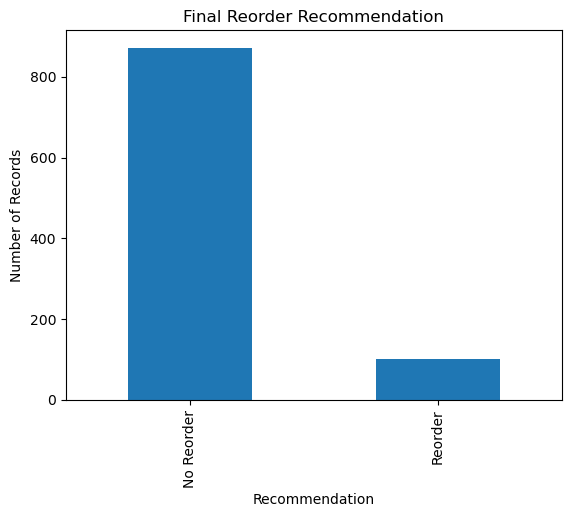

In [156]:
# Visualize final reorder recommendations
final_output["Recommended_Action"].value_counts().plot(
    kind="bar",
    title="Final Reorder Recommendation"
)

plt.xlabel("Recommendation")
plt.ylabel("Number of Records")
plt.show()

## Conclusion

The Retail Sales Demand Forecasting and Inventory Management System was developed using Python, Pandas, NumPy, Matplotlib, and Scikit-learn.

The project followed a complete machine learning workflow including data cleaning, exploratory data analysis, feature engineering, preprocessing, model training, evaluation, and business decision generation.

A Random Forest Regressor was selected for demand forecasting, achieving an MAE of 29.15 units and an RMSE of 129.47 units on the test data. The model showed limitations in predicting rare and unusually large demand spikes, which affected the overall R² score.

The final system converted demand predictions into practical inventory insights by comparing predicted demand with available inventory. Among 972 test records, 100 were identified as stock-risk cases requiring reorder action, while 872 were classified as no-reorder cases.

This project demonstrates how machine learning predictions can be combined with business rules to support demand planning and inventory management decisions.

In [157]:
# Check final notebook objects
print("DataFrame shape:", df.shape)
print("Final output shape:", final_output.shape)
print("Final model:", type(model_v3).__name__)
print("CSV file created: final_retail_demand_results.csv")

DataFrame shape: (4956, 22)
Final output shape: (972, 7)
Final model: RandomForestRegressor
CSV file created: final_retail_demand_results.csv
